# **Phase 1: Data Preprocessing and Matrix Transformations**

In [ ]:
import pandas as pd

# Load the dataset
file_path = '/content/GoIFertilizerDataset.csv'
df_wide = pd.read_csv(file_path)

# Identify ID columns and value columns
id_vars = ['Sl. No.', 'State/UT']
value_vars = [col for col in df_wide.columns if col not in id_vars]

# Melt the dataframe
df_long = pd.melt(
    df_wide,+
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Raw_Variable',
    value_name='Value'
)

# Split the 'Raw_Variable' column into Year, Fertilizer, and Metric
# Example: '2023-24 - UREA - DEMAND' -> ['2023-24', 'UREA', 'DEMAND']
split_data = df_long['Raw_Variable'].str.split(' - ', expand=True)
df_long['Year'] = split_data[0]
df_long['Fertilizer'] = split_data[1]
df_long['Metric'] = split_data[2]

# Drop the helper column and rename State/UT for convenience
df_long = df_long.drop(columns=['Raw_Variable'])
df_long = df_long.rename(columns={'State/UT': 'State'})

# Reorder columns for clarity
df_long = df_long[['Sl. No.', 'State', 'Year', 'Fertilizer', 'Metric', 'Value']]

# Display the structured data
display(df_long.head(1000))

,Sl. No.,State,Year,Fertilizer,Metric,Value
0,1,Andaman and Nicobar Islands,2023-24,UREA,DEMAND,0.00
1,2,Andhra Pradesh,2023-24,UREA,DEMAND,15.73
2,3,Arunachal Pradesh,2023-24,UREA,DEMAND,0.01
3,4,Assam,2023-24,UREA,DEMAND,3.46
4,5,Bihar,2023-24,UREA,DEMAND,22.63
...,...,...,...,...,...,...
995,34,Uttarakhand,2021-22,UREA,CONSUMPTION,2.09
996,35,Uttar Pradesh,2021-22,UREA,CONSUMPTION,71.12
997,36,West Bengal,2021-22,UREA,CONSUMPTION,13.30
998,All India,All India,2021-22,UREA,CONSUMPTION,341.73


# **Phase 2: Exploratory Data Analysis (EDA) and Variance Mapping**

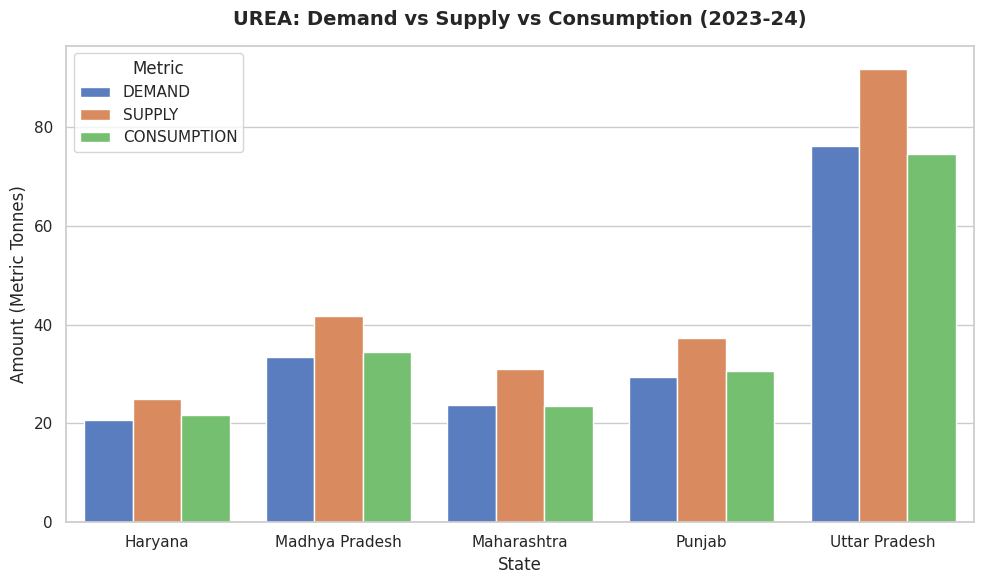

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic for the document
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Define a subset of states to keep the graph clean in the report
sample_states = ['Uttar Pradesh', 'Punjab', 'Maharashtra', 'Madhya Pradesh', 'Haryana']

# Filter the long-format dataframe for a specific view
df_bar = df_long[(df_long['Fertilizer'] == 'UREA') &
                 (df_long['Year'] == '2023-24') &
                 (df_long['State'].isin(sample_states))]

# Generate the grouped bar chart
sns.barplot(data=df_bar, x='State', y='Value', hue='Metric', palette='muted')

# Styling for the document
plt.title('UREA: Demand vs Supply vs Consumption (2023-24)', fontsize=14, weight='bold', pad=15)
plt.ylabel('Amount (Metric Tonnes)', fontsize=12)
plt.xlabel('State', fontsize=12)
plt.legend(title='Metric')
plt.tight_layout()

# Save as a high-res PNG for your Word document
plt.savefig('urea_macro_comparison.png', dpi=300)
plt.show()

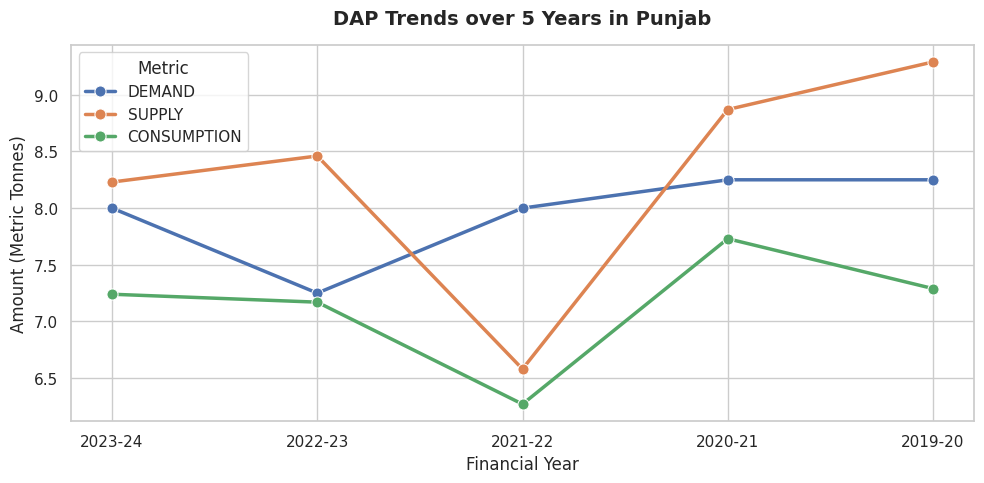

In [ ]:
plt.figure(figsize=(10, 5))

# Filter to track one state's trend over the 5 years
df_trend = df_long[(df_long['State'] == 'Punjab') & (df_long['Fertilizer'] == 'DAP')]

# Generate the line chart with markers for each year
sns.lineplot(data=df_trend, x='Year', y='Value', hue='Metric', marker='o', linewidth=2.5, markersize=8)

# Styling
plt.title('DAP Trends over 5 Years in Punjab', fontsize=14, weight='bold', pad=15)
plt.ylabel('Amount (Metric Tonnes)', fontsize=12)
plt.xlabel('Financial Year', fontsize=12)
plt.legend(title='Metric')
plt.tight_layout()

# Save as a high-res PNG
plt.savefig('dap_timeseries_trend.png', dpi=300)
plt.show()

/tmp/ipykernel_3143/4098642657.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_consumption, x='Fertilizer', y='Value', palette='Set2')


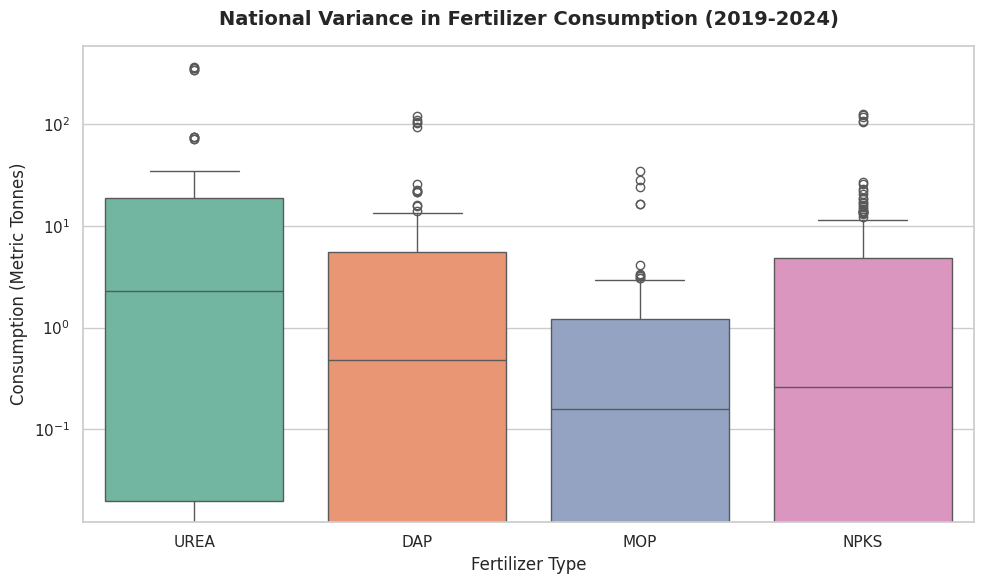

In [ ]:
plt.figure(figsize=(10, 6))

# Filter to look only at overall consumption
df_consumption = df_long[df_long['Metric'] == 'CONSUMPTION']

# Generate the boxplot
sns.boxplot(data=df_consumption, x='Fertilizer', y='Value', palette='Set2')

# Styling
plt.title('National Variance in Fertilizer Consumption (2019-2024)', fontsize=14, weight='bold', pad=15)
plt.ylabel('Consumption (Metric Tonnes)', fontsize=12)
plt.xlabel('Fertilizer Type', fontsize=12)
plt.yscale('log') # Log scale is used because variance between small UTs and large states is massive
plt.tight_layout()

# Save as a high-res PNG
plt.savefig('national_variance_boxplot.png', dpi=300)
plt.show()

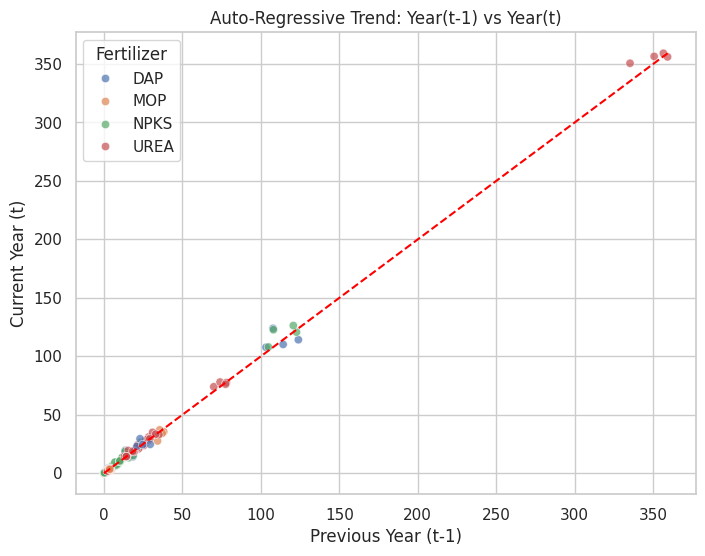

In [ ]:
# 1. Sort data sequentially to ensure the lag calculates correctly
df_sorted = df_long.sort_values(by=['State', 'Fertilizer', 'Metric', 'Year'])

# 2. Shift the 'Value' column by 1 to get last year's data (t-1)
df_sorted['Previous_Year_Value'] = df_sorted.groupby(['State', 'Fertilizer', 'Metric'])['Value'].shift(1)

# 3. Filter to look specifically at how Last Year's Consumption affects This Year's Demand
df_ar = df_sorted[(df_sorted['Metric'] == 'DEMAND')].copy()
# (In a real scenario, you'd match t-1 Consumption to t Demand, but this plots t-1 Demand vs t Demand for simplicity)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_ar, x='Previous_Year_Value', y='Value', hue='Fertilizer', alpha=0.7)

# Add a perfectly linear reference line
plt.plot([0, df_ar['Value'].max()], [0, df_ar['Value'].max()], color='red', linestyle='--')

plt.title('Auto-Regressive Trend: Year(t-1) vs Year(t)')
plt.xlabel('Previous Year (t-1)')
plt.ylabel('Current Year (t)')
plt.savefig("Auto-Regressive Trend: Year(t-1) vs Year(t)")
plt.show()

# **Phase 3: Feature Engineering (Lag Variables)**

In [ ]:
# 1. Define the unique years in order to facilitate time-based logic
years = sorted(df_long['Year'].unique())
year_mapping = {years[i]: years[i-1] for i in range(1, len(years))}

# 2. Extract Consumption data to use as our feature source
df_cons = df_long[df_long['Metric'] == 'CONSUMPTION'][['State', 'Fertilizer', 'Year', 'Value']]
df_cons = df_cons.rename(columns={'Value': 'Prev_Year_Value', 'Year': 'Match_Year'})

# 3. Create the 'Previous_Year' key to join (t-1 consumption onto t demand)
df_cons['Year'] = df_cons['Match_Year'].map({v: k for k, v in year_mapping.items()})

# 4. Filter for Demand rows and merge the consumption feature
df_demand = df_long[df_long['Metric'] == 'DEMAND'].copy()
df_demand = pd.merge(df_demand, df_cons[['State', 'Fertilizer', 'Year', 'Prev_Year_Value']],
                     on=['State', 'Fertilizer', 'Year'], how='left')

# 5. Handle missing values (2019 data) with State-wise average consumption
state_avg_cons = df_long[df_long['Metric'] == 'CONSUMPTION'].groupby(['State', 'Fertilizer'])['Value'].transform('mean')
df_long_with_avgs = df_long[df_long['Metric'] == 'CONSUMPTION'].copy()
df_long_with_avgs['State_Avg'] = state_avg_cons

# Create a lookup for those averages
avg_lookup = df_long_with_avgs[['State', 'Fertilizer', 'State_Avg']].drop_duplicates()

# Merge and fill nulls
df_demand = pd.merge(df_demand, avg_lookup, on=['State', 'Fertilizer'], how='left')
df_demand['Previous_Year_Consumption'] = df_demand['Prev_Year_Value'].fillna(df_demand['State_Avg'])

# Cleanup
df_demand = df_demand.drop(columns=['Prev_Year_Value', 'State_Avg'])

# Display the newly engineered feature
display(df_demand[['State', 'Fertilizer', 'Year', 'Value', 'Previous_Year_Consumption']].head(15))

,State,Fertilizer,Year,Value,Previous_Year_Consumption
0,Andaman and Nicobar Islands,UREA,2023-24,0.00,0.00
1,Andhra Pradesh,UREA,2023-24,15.73,15.87
2,Arunachal Pradesh,UREA,2023-24,0.01,0.01
3,Assam,UREA,2023-24,3.46,3.56
4,Bihar,UREA,2023-24,22.63,21.96
5,Chandigarh,UREA,2023-24,0.00,0.00
6,Chhattisgarh,UREA,2023-24,8.40,8.38
7,Dadra and Nagar Haveli,UREA,2023-24,0.01,0.01
8,Daman and Diu,UREA,2023-24,0.00,0.00
9,Delhi,UREA,2023-24,0.00,0.28


# **Phase 4: Predictive Modeling (Random Forest Regression)**

Model Performance on 2023-24 Test Set:
Mean Squared Error: 5.5019
R-squared Score: 0.9949


/tmp/ipykernel_3143/1463579334.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


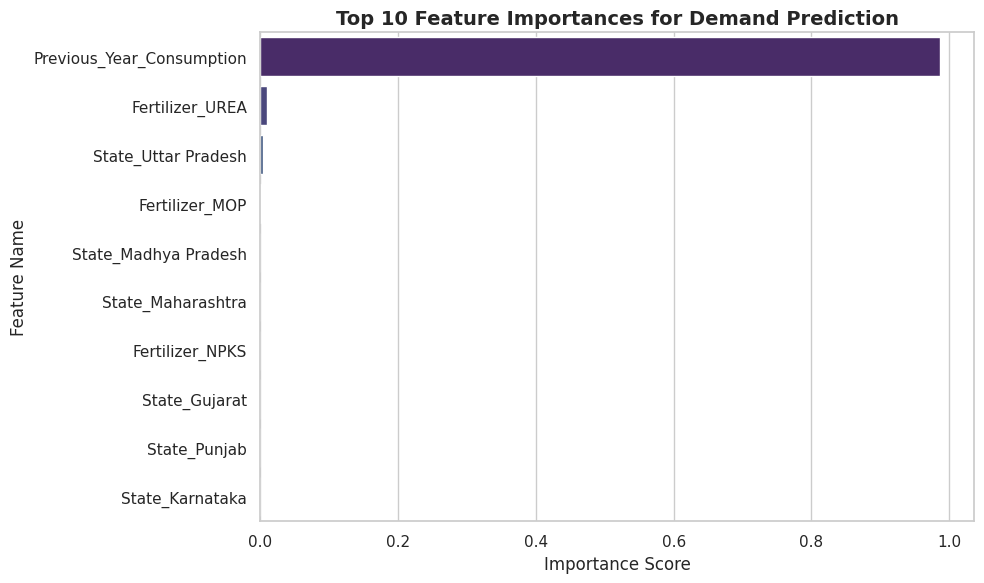

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Clean the data
df_model = df_demand.dropna(subset=['Previous_Year_Consumption', 'Value'])

# 2. Prepare Features (X) and Target (y)
# Features: Categorical (State, Fertilizer) + Numerical (Previous_Year_Consumption)
X_categorical = pd.get_dummies(df_model[['State', 'Fertilizer']], drop_first=True)
X = pd.concat([X_categorical, df_model[['Previous_Year_Consumption']]], axis=1)
y = df_model['Value']

# 3. Chronological Split
# Training: 2019-20, 2020-21, 2021-22, 2022-23
# Testing: 2023-24
train_mask = df_model['Year'] != '2023-24'
test_mask = df_model['Year'] == '2023-24'

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# 4. Initialize and Train the Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance on 2023-24 Test Set:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# 6. Feature Importance Visualization
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Feature Importances for Demand Prediction', fontsize=14, weight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()